In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device 

device(type='cuda')

In [4]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [6]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} # string to integer mapping
stoi['.'] = 0 # add a special character for "end of word"
itos = {i:s for s,i in stoi.items()} # integer to string mapping
vocab_size = len(stoi)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [7]:
 # build the dataset
block_size = 3 # context length: how many characters do we take to predict the next

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.': # for each character plus an "end of word" character
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
# utility function to compare manual gradients to PyTorch gradients
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [227]:
# MLP
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g, device=device)

W1 = torch.randn((n_embd * block_size, n_hidden), generator=g, device=device) * (5/3)/((n_embd*block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g, device=device) * 0.1

W2 = torch.randn((n_hidden, vocab_size), generator=g, device=device) * 0.1
b2 = torch.randn(vocab_size, generator=g, device=device) * 0.1

# batch normalization parameters
bngain = torch.rand((1, n_hidden), device=device) * 0.1 + 1.0
bnbias = torch.rand((1, n_hidden), device=device) * 0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in the model
for p in parameters:
    p.requires_grad = True

12297


In [228]:
batch_size = 32
n = batch_size
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (n,), generator=g, device=device)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [229]:

# forward pass
emb = C[Xb] # embed the characters into vectors, shape (batch_size, block_size, n_embd)
embcat = emb.view(emb.shape[0], -1) # concatenate the block of embeddings into a single vector, shape (batch_size, block_size * n_embd)
# linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation, shape (batch_size, n_hidden)
# batch normalization
bnmeani = 1/n * hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1) * bndiff2.sum(0, keepdim=True) # note: Bessel's correction (devide by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5 # inverse of standard deviation
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias # batch normalize hpreact to unit Gaussion

# non-linear activation
h = torch.tanh(hpreact) # hidden layer, shape (batch_size, n_hidden)
# linear layer 2
logits = h @ W2 + b2 # output layer, shape (batch_size, vocab_size)
# cross entropy loss
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
          embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.6685, device='cuda:0', grad_fn=<NegBackward0>)

In [230]:
b1.shape, db1.shape

(torch.Size([200]), torch.Size([200]))

In [231]:
# Excercise 1: backprop through the whole thing manully,
# backpropgating through exactly all of the variables
# as they are defined in the forward pass above, one by one

#loss = -logprobs[range(n), Yb].mean()
# loss = -(a + b + c)/3
# dloss/da = -1/3
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
cmp('logprobs', dlogprobs, logprobs)

# probs.log()
# dprobs = 1 / probs
dprobs = dlogprobs / probs
cmp('probs', dprobs, probs)

# probs = counts * counts_sum_inv 
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts = counts_sum_inv * dprobs
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
# counts_sum_inv = counts_sum**-1
dcounts_sum = -counts_sum**-2 * dcounts_sum_inv
cmp('counts_sum', dcounts_sum, counts_sum)
# counts_sum = counts.sum(1, keepdim=True)
dcounts += torch.ones_like(counts) * dcounts_sum
cmp('counts', dcounts, counts)
#counts = norm_logits.exp()
dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)
#norm_logits = logits - logit_maxes # for numerical stability
dlogit_maxes = -dnorm_logits.sum(1, keepdim=True)
dlogits = dnorm_logits.clone()
cmp('logit_maxes', dlogit_maxes, logit_maxes)
#logit_maxes = logits.max(1, keepdim=True).values
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
cmp('logits', dlogits, logits)
#logits = h @ W2 + b2 # output layer, shape (batch_size, vocab_size)
dh = dlogits @ W2.t()
cmp('h', dh, h)
dW2 = h.t() @ dlogits
cmp('W2', dW2, W2)
db2 = dlogits.sum(0)
cmp('b2', db2, b2)
#h = torch.tanh(hpreact)
dhpreact = (1.0 - h**2) * dh# derivative of tanh
cmp('hpreact', dhpreact, hpreact)

#hpreact = bngain * bnraw + bnbias # batch normalize hpreact to unit Gaussion
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
cmp('bngain', dbngain, bngain)
dbnbias = dhpreact.sum(0, keepdim=True)
cmp('bnbias', dbnbias, bnbias)
dbnraw = bngain * dhpreact
cmp('bnraw', dbnraw, bnraw)
#bnraw = bndiff * bnvar_inv
dbnbar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbndiff = dbnraw * bnvar_inv
cmp('bnvar_inv', dbnbar_inv, bnvar_inv)
#bnvar_inv = (bnvar + 1e-5)**-0.5 # inverse of standard deviation
dbvar = -0.5 * (bnvar + 1e-5)**-1.5 * dbnbar_inv
cmp('bnvar', dbvar, bnvar)
#bnvar = 1/(n-1) * bndiff2.sum(0, keepdim=True) # note: Bessel's correction (devide by n-1, not n)
dbndiff2 = (1.0/(n-1)) * torch.ones_like(bndiff2) * dbvar
cmp('bndiff2', dbndiff2, bndiff2)
#bndiff2 = bndiff**2
dbndiff += 2 * bndiff * dbndiff2
cmp('bndiff', dbndiff, bndiff)
#bndiff = hprebn - bnmeani
dbnmeani = (-dbndiff).sum(0, keepdim=True)
dhprebn = dbndiff.clone()
cmp('bnmeani', dbnmeani, bnmeani)
#bnmeani = 1/n * hprebn.sum(0, keepdim=True)
dhprebn += 1.0/n * dbnmeani
cmp('hprebn', dhprebn, hprebn)
#hprebn = embcat @ W1 + b1 # hidden layer pre-activation, shape (batch_size, n_hidden)
dembcat = dhprebn @ W1.t()
cmp('embcat', dembcat, embcat)
dW1 = embcat.t() @ dhprebn
cmp('W1', dW1, W1)
db1 = dhprebn.sum(0)
cmp('b1', db1, b1)
#embcat = emb.view(emb.shape[0], -1) # concatenate the block of embeddings into a single vector, shape (batch_size, block_size * n_embd)
demb = dembcat.view(emb.shape)
cmp('emb', demb, emb)
#emb = C[Xb] # embed the characters into vectors, shape (batch_size, block_size, n_embd)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10
bngain          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnbias          | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
bnraw   

In [232]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass
# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdim=True)
# counts_sum_inv = counts_sum**-1
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.6684718132019043 diff: 0.0


In [233]:
# backward pass

dlogits = F.softmax(logits, dim=1)
dlogits[range(n), Yb] -= 1.0
dlogits /= n

cmp('logits', dlogits, logits) # expect maxdiff to be 6e-9 or less

logits          | exact: False | approximate: True  | maxdiff: 4.190951585769653e-09


In [234]:
dlogits[0].sum()

tensor(0., device='cuda:0', grad_fn=<SumBackward0>)

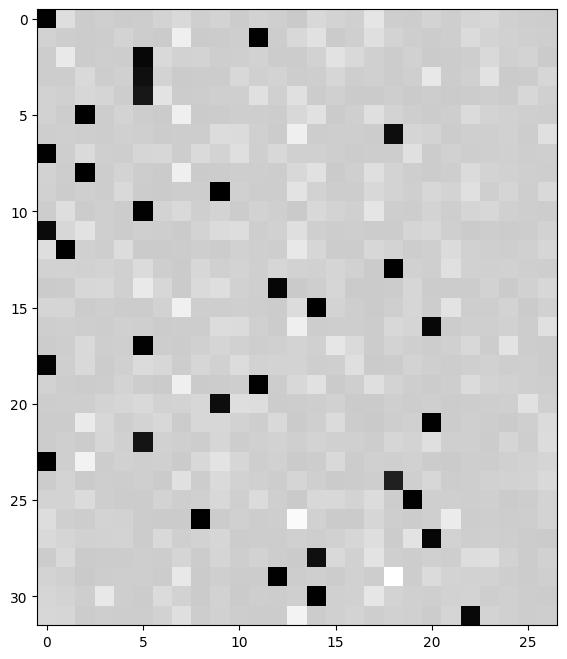

In [235]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach().cpu(), cmap='gray')

In [236]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of batchnorm,
# take the derivative, simplify the expression, and just write it out

# forward pass
# before:
# bnmeani = 1/n * hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1) * bndiff2.sum(0, keepdim=True) # note: Bessel's correction (devide by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5 # inverse of standard deviation
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias # batch normalize hpreact to unit Gaussion

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print(hpreact_fast, 'max dif:', (hpreact_fast - hpreact).abs().max().item())

tensor([[ 0.6750, -1.7118,  0.1503,  ...,  1.1908, -1.2074,  0.7203],
        [-0.3386,  0.5175,  1.6600,  ..., -0.6854,  1.5224, -1.1536],
        [ 0.4252, -1.3977,  1.5428,  ...,  1.4302,  0.4522, -0.2657],
        ...,
        [-0.9712, -1.0105,  1.1461,  ..., -0.1792, -0.7881,  0.4770],
        [ 1.0484,  0.9504,  0.2738,  ..., -2.5436, -0.7555, -0.2245],
        [-0.2358,  0.4819,  0.5536,  ..., -0.8782,  0.1503, -0.9939]],
       device='cuda:0', grad_fn=<AddBackward0>) max dif: 7.152557373046875e-07


In [237]:
# backward pass. just implement dhprebn, ignore the gamma and beta, which we've derived already in Exercise 1

dhprebn = bngain * bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1) *bnraw * (dhpreact * bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # expect maxdiff to be 9e-10 or less

hprebn          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09


In [257]:
# Excercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# MLP
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g, device=device)

W1 = torch.randn((n_embd * block_size, n_hidden), generator=g, device=device) * (5/3)/((n_embd*block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g, device=device) * 0.1

W2 = torch.randn((n_hidden, vocab_size), generator=g, device=device) * 0.1
b2 = torch.randn(vocab_size, generator=g, device=device) * 0.1

# batch normalization parameters
bngain = torch.rand((1, n_hidden), device=device) * 0.1 + 1.0
bnbias = torch.rand((1, n_hidden), device=device) * 0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in the model
for p in parameters:
    p.requires_grad = True

# same training loop as before, but with your own backward pass and no autograd
max_steps = 200000
batch_size = 32
n = batch_size
lossi = []

# can uncomment this to use pure manual backprop without autograd, but then you won't be able to compare your gradients to autograd's gradients, which is a useful sanity check
#with torch.no_grad():

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device=device)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X and Y, both of shape (batch_size, block_size) and (batch_size,) respectively

    # forward pass
    emb = C[Xb] # embed the characters into vectors, shape (batch_size, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concatenate the block of embeddings into a single vector, shape (batch_size, block_size * n_embd)
    # linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation, shape (batch_size, n_hidden)
    # batch normalization
    bnmeani = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmeani) * bnvar_inv
    hpreact = bngain * bnraw + bnbias # batch normalize hpreact to unit Gaussion

    # non-linear activation
    h = torch.tanh(hpreact) # hidden layer, shape (batch_size, n_hidden)
    logits = h @ W2 + b2 # output layer, shape (batch_size, vocab_size)
    loss = F.cross_entropy(logits, Yb) # loss function, shape (1,)

    # backward pass
    # if you need to debug your backward pass, you can retain the gradients of all the intermediate variables and compare them to autograd's gradients, but this will slow down training a lot, so you might want to only do it for a few iterations, or only for a subset of the variables
    # for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
    #       norm_logits, logit_maxes, logits, h, hpreact, bnraw,
    #       bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
    #       embcat, emb]:
    #     t.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward() # for comparison, compute the gradients with autograd, and compare to your own gradients from Exercise 1 and 2

    # manual backprop
    dlogits = F.softmax(logits, dim=1)
    dlogits[range(n), Yb] -= 1.0
    dlogits /= n
    # 2nd layer
    dh = dlogits @ W2.t()
    dW2 = h.t() @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1.0 - h**2) * dh
    # batchnorm
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain * bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1) *bnraw * (dhpreact * bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.t()
    dW1 = embcat.t() @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding layer
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
        for j in range(Xb.shape[1]):
            ix = Xb[k,j]
            dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------
    # parameters = [C, W1, b1, W2, b2, bngain, bnbias]

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p, grad in zip(parameters, grads):
        p.data += -lr * grad   

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    if i >= 100:
        break
    #break

12297
      0/200000: 3.6646


In [258]:
#cmp('dhprebn', dhprebn, hprebn)

for p,g in zip(parameters, grads):
    cmp(str(tuple(p.shape)), g, p)

(27, 10)        | exact: False | approximate: True  | maxdiff: 1.30385160446167e-08
(30, 200)       | exact: False | approximate: True  | maxdiff: 9.313225746154785e-09
(200,)          | exact: False | approximate: True  | maxdiff: 4.6566128730773926e-09
(200, 27)       | exact: False | approximate: True  | maxdiff: 9.313225746154785e-09
(27,)           | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 2.7939677238464355e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09


In [259]:
# calibrate the batch normalization at the end of training
with torch.no_grad():
    # pass the training set through the network and update the batch normalization parameters
    emb = C[Xtr] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # (N, n_hidden)
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [260]:
@torch.no_grad() # we don't need gradients for sampling
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (num_examples, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (num_examples, block_size * n_embd)
    hpreact = embcat @ W1 #+ b1 # (num_examples, n_hidden)
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias # batch normalize hpreact to unit Gaussion
    h = torch.tanh(hpreact) # (num_examples, n_hidden)
    logits = h @ W2 + b2 # (num_examples, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('val')


train loss: 2.6914
val loss: 2.6893
